# Explore GEMS O3 Retrieval Uncertainty

This notebook is a read-only diagnostic for the GEMS total column ozone NetCDF products. It does **not** modify the existing CSV/pickle preprocessing or modeling pipeline.

Goal: inspect whether the O3 product contains a measurement/retrieval uncertainty variable analogous to `ColumnUncertainty` in other GEMS products, then examine its spatial pattern and relation to viewing geometry.


In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from PIL import Image
from matplotlib.patches import Polygon

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="xarray")

GEMS_TCO_PATH = Path("/Users/joonwonlee/Documents/GEMS_TCO-1/src")
sys.path.append(str(GEMS_TCO_PATH))

from GEMS_TCO import configuration as config
from GEMS_TCO import data_preprocess as dmbh

RAW_ROOT = Path("/Volumes/Backup Plus/GEMS_UNZIPPED")
OUT_DIR = Path("/Users/joonwonlee/Documents/GEMS_TCO-1/outputs/uncertainty_exploration")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Match the nugget heatmap comparison window.
ANALYSIS_YEAR = 2022
ANALYSIS_MONTH = 7
LAT_RANGE = (-3.0, 7.0)
LON_RANGE = (111.0, 131.0)
NADIR_LON, NADIR_LAT = 128.0, 0.0

# Existing modeling region, useful for comparison with prior EDA notebooks.
FOCUSED_LAT_RANGE = (-3.0, 2.0)
FOCUSED_LON_RANGE = (121.0, 131.0)

ACCEPTABLE_FLAGS = [0, 2]

# Map-style background for geographic tile plots.  The schematic background is drawn
# directly with matplotlib so the notebook works without cartopy/geopandas.
USE_SCHEMATIC_MAP_BACKGROUND = True

# Optional clean raster background. Use only a map-only image here; the Gemini example
# already contains nugget labels/colorbars, so it is intentionally off by default.
USE_RASTER_MAP_BACKGROUND = False
MAP_BACKGROUND_PATH = Path("/Users/joonwonlee/Downloads/Gemini_Generated_Image_xtvlcdxtvlcdxtvl.png")
MAP_BACKGROUND_CROP = None  # e.g. (left, upper, right, lower) in pixels if the image has margins.
MAP_BACKGROUND_ALPHA = 0.70
TILE_ALPHA_WITH_BACKGROUND = 0.58
TILE_ALPHA_NO_BACKGROUND = 1.00

print(f"RAW_ROOT exists: {RAW_ROOT.exists()} -> {RAW_ROOT}")
print(f"Output directory: {OUT_DIR}")


RAW_ROOT exists: True -> /Volumes/Backup Plus/GEMS_UNZIPPED
Output directory: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/uncertainty_exploration


## Pick a Sample O3 NetCDF File

The paths below follow the same raw-data layout used by `step2_truncate_cvs_pickle_by_monthyear_020226.ipynb`. You can change `SAMPLE_FILE` manually if you want a different date/slot.


In [2]:
def month_day_suffix(month: int, year: int | None = None) -> str:
    if month == 2:
        if year == 2024:
            return "0129"
        return "0128"
    return "0131" if month in [1, 3, 5, 7, 8, 10, 12] else "0130"


def candidate_file(year: int, month: int, day: int, slot_hour: int) -> Path:
    suffix = month_day_suffix(month, year)
    return RAW_ROOT / f"{year}{month:02d}{suffix}" / f"{year}{month:02d}{day:02d}_{slot_hour:02d}45.nc"

CANDIDATES = [
    candidate_file(ANALYSIS_YEAR, ANALYSIS_MONTH, 1, 0),
    candidate_file(ANALYSIS_YEAR, ANALYSIS_MONTH, 14, 2),
    candidate_file(2022, 7, 1, 0),
    candidate_file(2023, 7, 1, 0),
    candidate_file(2024, 7, 1, 0),
    candidate_file(2025, 7, 1, 0),
]

SAMPLE_FILE = next((p for p in CANDIDATES if p.exists() and not p.name.startswith("._")), None)
if SAMPLE_FILE is None:
    raise FileNotFoundError("No sample GEMS O3 NetCDF file found. Update RAW_ROOT or CANDIDATES.")

print("Using sample file:")
print(SAMPLE_FILE)


Using sample file:
/Volumes/Backup Plus/GEMS_UNZIPPED/2022070131/20220701_0045.nc


## List Groups and Candidate Uncertainty Variables

For this O3 product, the uncertainty-like variable appears to be `EstimatedError` in `Data Fields`.


In [3]:
def summarize_nc_variables(file_path: Path) -> pd.DataFrame:
    rows = []
    with Dataset(file_path) as ds:
        for group_name, group in ds.groups.items():
            for var_name, var in group.variables.items():
                attrs = {name: getattr(var, name) for name in var.ncattrs()}
                rows.append({
                    "group": group_name,
                    "variable": var_name,
                    "dims": tuple(var.dimensions),
                    "shape": tuple(var.shape),
                    "dtype": str(var.dtype),
                    "units": attrs.get("units", ""),
                    "long_name": attrs.get("long_name", attrs.get("Title", "")),
                    "description": attrs.get("description", ""),
                })
    return pd.DataFrame(rows)

var_summary = summarize_nc_variables(SAMPLE_FILE)
print(var_summary.to_string(index=False, max_colwidth=80))

uncertainty_like = var_summary[
    var_summary["variable"].str.contains("uncert|error|estimated", case=False, regex=True)
].copy()
print("\nUncertainty/error-like variables:")
print(uncertainty_like.to_string(index=False, max_colwidth=100))


             group                  variable                               dims               shape   dtype                                     units                                                                        long_name description
       Data Fields           AveragingKernel (nlayer2, nlayer2, spatial, image) (11, 11, 2048, 695) float32                                  unitless                                                          Averaging Kernel Matrix            
       Data Fields             CloudPressure                   (spatial, image)         (2048, 695) float32                                       hPa                               Cloud Centroid Pressure from GEMS L2 cloud prodcut            
       Data Fields            ColumnAmountO3                   (spatial, image)         (2048, 695) float32                                        DU                                                        Best Total Ozone Solution            
       Data Fields DegreesOf

## Load O3, EstimatedError, Quality Flags, and Geometry

This mirrors the existing extraction logic, but adds `EstimatedError`, `ViewingZenithAngle`, and `SolarZenithAngle` for diagnostic analysis.


In [4]:
def load_o3_uncertainty_frame(file_path: Path) -> pd.DataFrame:
    geo_vars = ["Latitude", "Longitude", "Time", "ViewingZenithAngle", "SolarZenithAngle", "GroundPixelQualityFlags"]
    data_vars = ["ColumnAmountO3", "EstimatedError", "FinalAlgorithmFlags"]

    with xr.open_dataset(file_path, group="Geolocation Fields") as geo, xr.open_dataset(file_path, group="Data Fields") as data:
        available_geo = [v for v in geo_vars if v in geo]
        available_data = [v for v in data_vars if v in data]

        missing_geo = sorted(set(geo_vars) - set(available_geo))
        missing_data = sorted(set(data_vars) - set(available_data))
        if missing_geo:
            print("Missing geolocation variables:", missing_geo)
        if missing_data:
            print("Missing data variables:", missing_data)

        geo_df = geo[available_geo].to_dataframe().reset_index(drop=True)
        data_df = data[available_data].to_dataframe().reset_index(drop=True)

    df = pd.concat([geo_df, data_df], axis=1)

    numeric_cols = [
        "Latitude", "Longitude", "Time", "ViewingZenithAngle", "SolarZenithAngle",
        "GroundPixelQualityFlags", "ColumnAmountO3", "EstimatedError", "FinalAlgorithmFlags",
    ]
    for col in numeric_cols:
        if col in df:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

raw_df = load_o3_uncertainty_frame(SAMPLE_FILE)
print(raw_df.head())
print("\nShape:", raw_df.shape)
print("Columns:", raw_df.columns.tolist())
print("\nMissing counts:")
print(raw_df.isna().sum().to_string())


    Latitude   Longitude                 Time  ViewingZenithAngle  \
0  45.815250  144.018768  1656636307598999936           54.950359   
1  45.811680  143.918182  1656636310152999936           54.918644   
2  45.808064  143.818024  1656636312707000064           54.887154   
3  45.804176  143.717377  1656636315261000064           54.855408   
4  45.800289  143.616928  1656636317815000064           54.823872   

   SolarZenithAngle  GroundPixelQualityFlags  ColumnAmountO3  EstimatedError  \
0         30.759048                      0.0       85.519485        2.311965   
1         30.805685                      0.0       94.948105        2.092988   
2         30.852163                      0.0       87.088829        2.090316   
3         30.898842                      0.0       86.971161        2.177316   
4         30.945505                      0.0       83.085342        2.211006   

   FinalAlgorithmFlags  
0                129.0  
1                129.0  
2                129.0  
3   

## Region and Quality Filtering

This does not save any processed file. It only reproduces the filtering idea used in the current pipeline so we can inspect uncertainty values for pixels that would enter the analysis.


In [5]:
def filter_region_quality(df: pd.DataFrame, lat_range=LAT_RANGE, lon_range=LON_RANGE, flags=ACCEPTABLE_FLAGS) -> pd.DataFrame:
    out = df.copy()
    out = out[
        out["Latitude"].between(lat_range[0], lat_range[1])
        & out["Longitude"].between(lon_range[0], lon_range[1])
    ]
    out = out.dropna(subset=["Latitude", "Longitude", "ColumnAmountO3", "EstimatedError", "FinalAlgorithmFlags"])

    # Existing preprocessing excludes fill/bad O3 values with ColumnAmountO3 < 1000.
    out = out[out["ColumnAmountO3"] < 1000]
    out["is_good_flag"] = out["FinalAlgorithmFlags"].isin(flags)
    return out

region_df = filter_region_quality(raw_df)
good_df = region_df[region_df["is_good_flag"]].copy()
assert set(good_df["FinalAlgorithmFlags"].dropna().unique()).issubset(set(ACCEPTABLE_FLAGS))

print("Region rows:", len(region_df))
print(f"Good-flag rows, FinalAlgorithmFlags in {ACCEPTABLE_FLAGS}:", len(good_df))
print("Good fraction:", len(good_df) / len(region_df) if len(region_df) else np.nan)
print("Good flags present:", sorted(good_df["FinalAlgorithmFlags"].dropna().unique().tolist()))
print("\nFinalAlgorithmFlags counts in region:")
print(region_df["FinalAlgorithmFlags"].value_counts(dropna=False).sort_index().to_string())

summary_cols = ["ColumnAmountO3", "EstimatedError", "ViewingZenithAngle", "SolarZenithAngle"]
print("\nGood-flag summary:")
print(good_df[summary_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).to_string())


Region rows: 144368
Good-flag rows, FinalAlgorithmFlags in [0, 2]: 141752
Good fraction: 0.9818796409176549
Good flags present: [0.0, 2.0]

FinalAlgorithmFlags counts in region:
FinalAlgorithmFlags
0.0      139890
2.0        1862
129.0      2438
131.0       178

Good-flag summary:
       ColumnAmountO3  EstimatedError  ViewingZenithAngle  SolarZenithAngle
count   141752.000000   141752.000000       141752.000000     141752.000000
mean       248.312271        1.088313           10.039336         49.022884
std          6.679771        0.359746            5.591779          4.384877
min        231.764526        0.366321            0.033825         39.373436
1%         236.606339        0.468903            0.920206         40.588712
5%         238.273129        0.545328            2.058531         42.054928
50%        248.094711        1.109970            9.297207         48.934626
95%        258.821136        1.713044           19.455738         56.051964
99%        261.413054        2.179

## Basic Distributions and Geometry Relationships

Use these quick plots to see whether `EstimatedError` varies systematically with viewing/solar geometry.


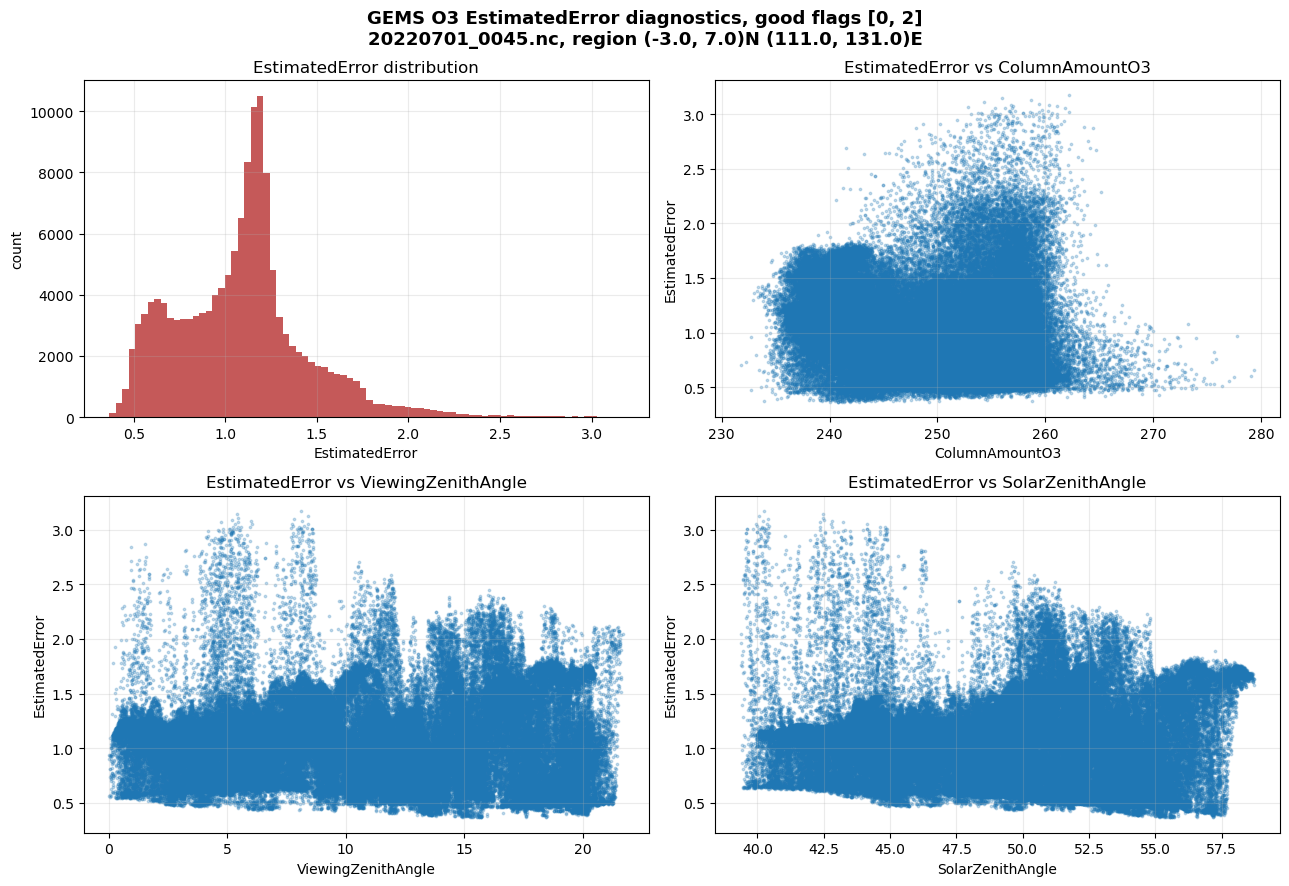

                    EstimatedError  ColumnAmountO3  ViewingZenithAngle  SolarZenithAngle
EstimatedError               1.000          -0.146              -0.027             0.002
ColumnAmountO3              -0.146           1.000               0.449             0.050
ViewingZenithAngle          -0.027           0.449               1.000             0.847
SolarZenithAngle             0.002           0.050               0.847             1.000


In [6]:
plot_df = good_df.copy()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(f"GEMS O3 EstimatedError diagnostics, good flags {ACCEPTABLE_FLAGS}\n{SAMPLE_FILE.name}, region {LAT_RANGE}N {LON_RANGE}E", fontsize=13, fontweight="bold")

axes[0, 0].hist(plot_df["EstimatedError"].dropna(), bins=80, color="firebrick", alpha=0.75)
axes[0, 0].set_title("EstimatedError distribution")
axes[0, 0].set_xlabel("EstimatedError")
axes[0, 0].set_ylabel("count")

axes[0, 1].scatter(plot_df["ColumnAmountO3"], plot_df["EstimatedError"], s=3, alpha=0.25)
axes[0, 1].set_title("EstimatedError vs ColumnAmountO3")
axes[0, 1].set_xlabel("ColumnAmountO3")
axes[0, 1].set_ylabel("EstimatedError")

axes[1, 0].scatter(plot_df["ViewingZenithAngle"], plot_df["EstimatedError"], s=3, alpha=0.25)
axes[1, 0].set_title("EstimatedError vs ViewingZenithAngle")
axes[1, 0].set_xlabel("ViewingZenithAngle")
axes[1, 0].set_ylabel("EstimatedError")

axes[1, 1].scatter(plot_df["SolarZenithAngle"], plot_df["EstimatedError"], s=3, alpha=0.25)
axes[1, 1].set_title("EstimatedError vs SolarZenithAngle")
axes[1, 1].set_xlabel("SolarZenithAngle")
axes[1, 1].set_ylabel("EstimatedError")

for ax in axes.ravel():
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig(OUT_DIR / f"estimated_error_basic_{SAMPLE_FILE.stem}.png", dpi=130, bbox_inches="tight")
plt.show()

corr_cols = ["EstimatedError", "ColumnAmountO3", "ViewingZenithAngle", "SolarZenithAngle"]
print(plot_df[corr_cols].corr().round(3).to_string())


## Spatial Map for One Orbit

This shows whether the uncertainty is smaller near the GEMS sub-satellite point region or follows another spatial pattern.


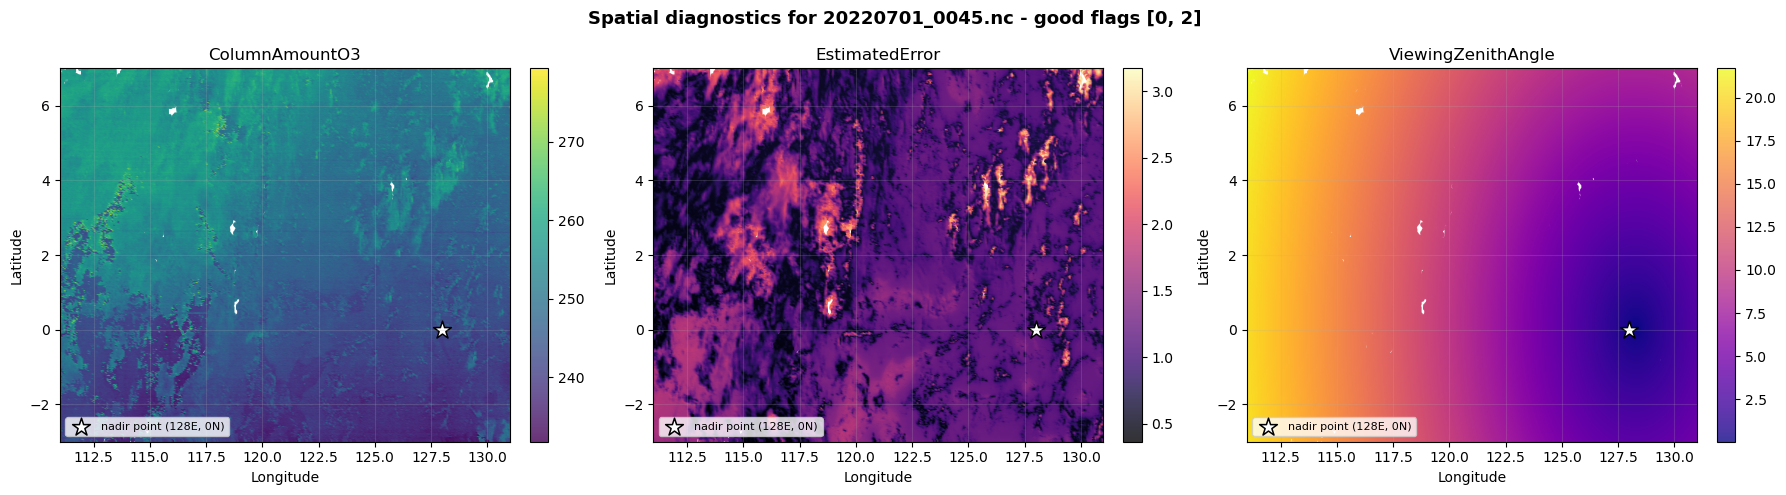

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Spatial diagnostics for {SAMPLE_FILE.name} - good flags {ACCEPTABLE_FLAGS}", fontsize=13, fontweight="bold")

for ax, col, title, cmap in [
    (axes[0], "ColumnAmountO3", "ColumnAmountO3", "viridis"),
    (axes[1], "EstimatedError", "EstimatedError", "magma"),
    (axes[2], "ViewingZenithAngle", "ViewingZenithAngle", "plasma"),
]:
    sc = ax.scatter(good_df["Longitude"], good_df["Latitude"], c=good_df[col], s=4, cmap=cmap, alpha=0.8)
    ax.scatter([NADIR_LON], [NADIR_LAT], marker="*", c="white", edgecolors="black", s=180, linewidths=1.1, label="nadir point (128E, 0N)")
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_xlim(LON_RANGE)
    ax.set_ylim(LAT_RANGE)
    ax.legend(fontsize=8, loc="best")
    plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(OUT_DIR / f"estimated_error_spatial_{SAMPLE_FILE.stem}.png", dpi=130, bbox_inches="tight")
plt.show()


## Tile-Level Summary

This matches the 4x8 geographic tile view used in the short-scale variability discussion. `EstimatedError` is treated as the retrieved O3 estimated error from the OEM-style retrieval output. Strictly speaking it is an absolute estimated error, not an error rate; an error-rate view is computed as `EstimatedError / ColumnAmountO3 * 100` when tile-level O3 summaries are available.


 tile_y  tile_x    n  median_error  mean_error  median_vza  median_sza  median_o3  median_error_pct
      0       0 4290      1.574155    1.412631   18.927456   57.217300 241.337616          0.652263
      0       1 4187      1.062629    1.069164   15.984461   55.362099 239.694412          0.443326
      0       2 4368      0.941131    0.926789   13.130133   53.602665 242.750549          0.387695
      0       3 4551      1.362060    1.326972   10.260875   51.825672 240.913376          0.565373
      0       4 4581      1.276681    1.243106    7.414369   50.062935 239.753647          0.532497
      0       5 4596      1.177739    1.098369    4.714256   48.327866 239.407043          0.491940
      0       6 4597      1.154892    1.095668    2.601193   46.625309 239.210022          0.482794
      0       7 4625      1.135560    1.059382    2.930907   44.943153 240.231171          0.472695
      1       0 4297      1.068653    1.072582   18.871468   56.045540 248.593491          0.429880


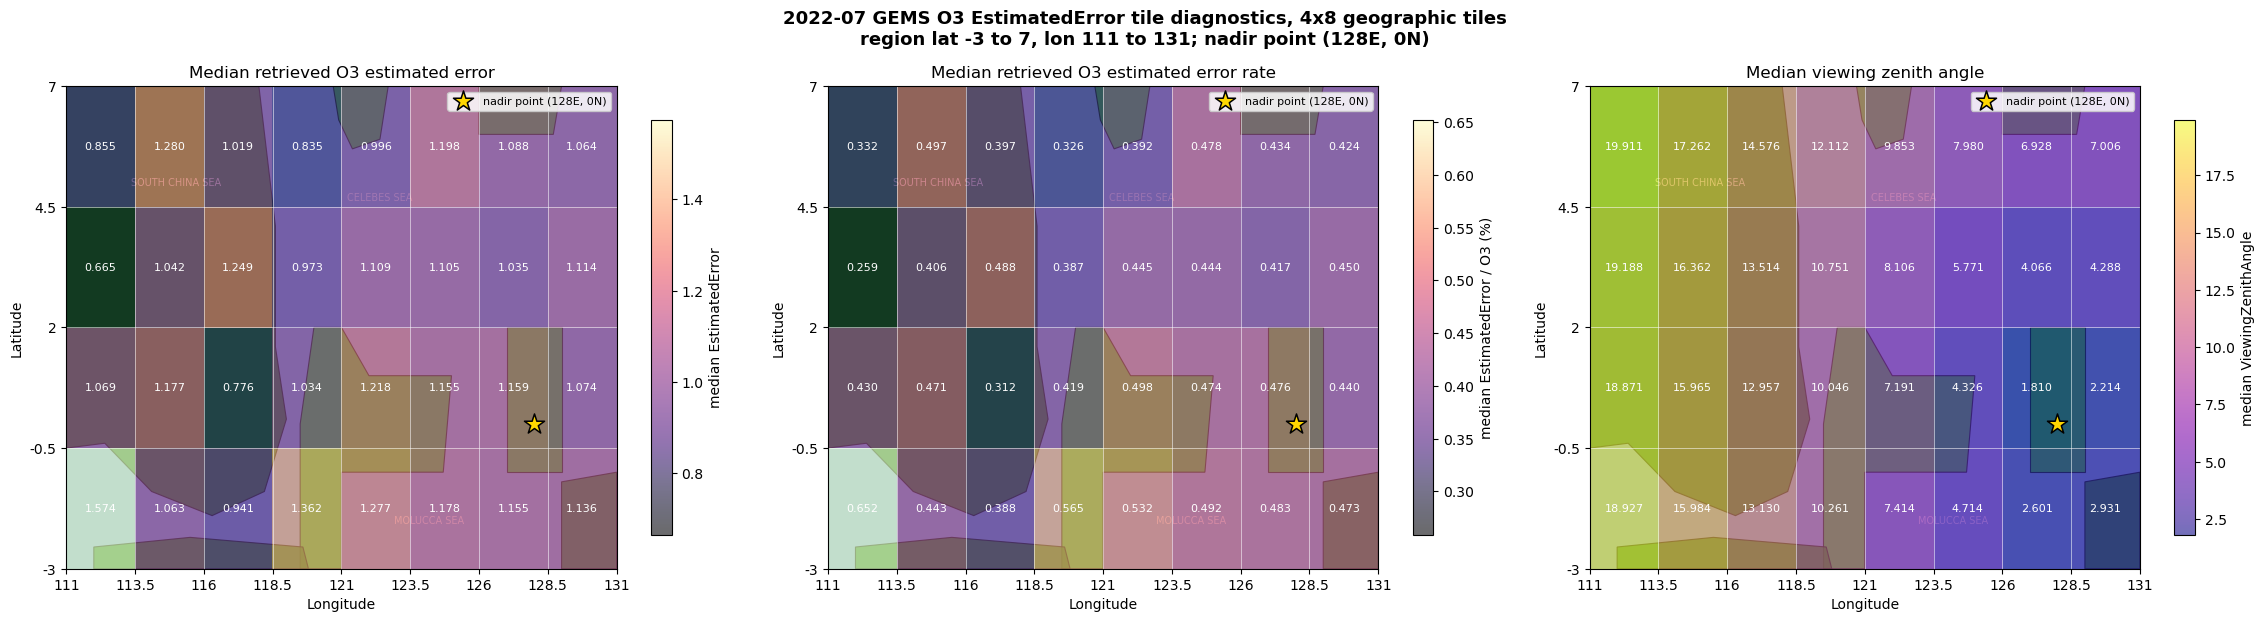

Saved: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/uncertainty_exploration/estimated_error_tile_geo_20220701_0045.png


In [8]:
def add_tile_indices(df: pd.DataFrame, lat_range=LAT_RANGE, lon_range=LON_RANGE, ny=4, nx=8) -> pd.DataFrame:
    out = df.copy()
    lat_edges = np.linspace(lat_range[0], lat_range[1], ny + 1)
    lon_edges = np.linspace(lon_range[0], lon_range[1], nx + 1)

    out["tile_y"] = pd.cut(out["Latitude"], bins=lat_edges, labels=False, include_lowest=True)
    out["tile_x"] = pd.cut(out["Longitude"], bins=lon_edges, labels=False, include_lowest=True)
    return out.dropna(subset=["tile_y", "tile_x"]).assign(
        tile_y=lambda d: d["tile_y"].astype(int),
        tile_x=lambda d: d["tile_x"].astype(int),
    )


def _fmt_geo_tick(x: float) -> str:
    return f"{x:.2f}".rstrip("0").rstrip(".")


def _load_map_background():
    if not USE_RASTER_MAP_BACKGROUND or MAP_BACKGROUND_PATH is None or not Path(MAP_BACKGROUND_PATH).exists():
        return None
    img = Image.open(MAP_BACKGROUND_PATH).convert("RGB")
    if MAP_BACKGROUND_CROP is not None:
        img = img.crop(MAP_BACKGROUND_CROP)
    return np.asarray(img)




def _draw_schematic_map_background(ax):
    if not USE_SCHEMATIC_MAP_BACKGROUND:
        return

    # Coarse regional land/water context for comparison with the nugget tile map.
    # It is not a coastline product; it is a lightweight geographic guide.
    ax.set_facecolor("#77b7de")
    land_specs = [
        ("Borneo / Kalimantan", [(111.0, 7.0), (118.0, 7.0), (118.6, 4.1), (118.6, 1.6),
                                  (119.0, 0.1), (118.2, -1.4), (116.3, -1.9), (114.1, -1.4),
                                  (112.4, -0.4), (111.0, -0.5)], "#1b7f2a"),
        ("Sulawesi", [(119.5, -3.0), (121.0, -3.0), (121.0, -1.0), (124.7, -1.0),
                       (125.0, 1.0), (122.0, 1.0), (121.0, 2.0), (120.0, 2.0),
                       (119.5, 0.0)], "#2fcf32"),
        ("Mindanao", [(126.0, 6.0), (128.7, 6.0), (129.0, 7.0), (126.0, 7.0)], "#2fbf38"),
        ("Halmahera", [(127.0, -1.0), (129.0, -1.0), (129.0, 2.0), (127.0, 2.0)], "#2fcf32"),
        ("Java / Lesser Sunda", [(112.0, -3.0), (119.8, -3.0), (119.6, -2.55),
                                  (115.5, -2.35), (112.0, -2.55)], "#208f2a"),
        ("Philippines", [(120.7, 7.0), (122.7, 7.0), (122.4, 5.9), (121.4, 5.7),
                         (120.9, 6.3)], "#2fbf38"),
        ("West Papua", [(129.0, -3.0), (131.0, -3.0), (131.0, -1.0), (129.0, -1.2)], "#238f35"),
    ]
    for _, coords, color in land_specs:
        ax.add_patch(
            Polygon(coords, closed=True, facecolor=color, edgecolor="#07351f", lw=0.8, alpha=0.82, zorder=0)
        )

    label_style = dict(color="white", fontsize=7, alpha=0.65, ha="center", va="center", zorder=0.2)
    ax.text(115.0, 5.0, "SOUTH CHINA SEA", **label_style)
    ax.text(122.4, 4.7, "CELEBES SEA", **label_style)
    ax.text(124.2, -2.0, "MOLUCCA SEA", **label_style)


def tile_matrix(summary: pd.DataFrame, value_col: str, ny=4, nx=8) -> np.ndarray:
    mat = np.full((ny, nx), np.nan, dtype=float)
    for row in summary.itertuples(index=False):
        mat[int(row.tile_y), int(row.tile_x)] = float(getattr(row, value_col))
    return mat


def draw_geo_tile_heatmap(ax, mat, title, cbar_label, cmap="magma", background=None):
    ny, nx = mat.shape
    lat_edges = np.linspace(LAT_RANGE[0], LAT_RANGE[1], ny + 1)
    lon_edges = np.linspace(LON_RANGE[0], LON_RANGE[1], nx + 1)
    extent = [lon_edges[0], lon_edges[-1], lat_edges[0], lat_edges[-1]]

    has_background = bool(USE_SCHEMATIC_MAP_BACKGROUND) or background is not None
    if USE_SCHEMATIC_MAP_BACKGROUND:
        _draw_schematic_map_background(ax)
    if background is not None:
        ax.imshow(background, extent=extent, origin="upper", aspect="auto", alpha=MAP_BACKGROUND_ALPHA, zorder=0)
    tile_alpha = TILE_ALPHA_WITH_BACKGROUND if has_background else TILE_ALPHA_NO_BACKGROUND

    masked = np.ma.masked_invalid(mat)
    im = ax.imshow(masked, origin="lower", cmap=cmap, extent=extent, aspect="auto", alpha=tile_alpha, zorder=1)

    for lon in lon_edges:
        ax.axvline(lon, color="white", lw=0.7, alpha=0.55, zorder=2)
    for lat in lat_edges:
        ax.axhline(lat, color="white", lw=0.7, alpha=0.55, zorder=2)

    lon_centers = 0.5 * (lon_edges[:-1] + lon_edges[1:])
    lat_centers = 0.5 * (lat_edges[:-1] + lat_edges[1:])
    finite_vals = mat[np.isfinite(mat)]
    vmin = float(np.nanmin(finite_vals)) if finite_vals.size else 0.0
    vmax = float(np.nanmax(finite_vals)) if finite_vals.size else 1.0
    threshold = vmin + 0.55 * (vmax - vmin)

    for y_idx, lat in enumerate(lat_centers):
        for x_idx, lon in enumerate(lon_centers):
            val = mat[y_idx, x_idx]
            if not np.isfinite(val):
                ax.text(lon, lat, "NA", ha="center", va="center", fontsize=8, color="white", zorder=3)
                continue
            color = "white" if (has_background or val > threshold) else "black"
            ax.text(lon, lat, f"{val:.3f}", ha="center", va="center", fontsize=8, color=color, zorder=3)

    ax.scatter(
        [NADIR_LON], [NADIR_LAT], marker="*", s=230, c="gold",
        edgecolors="black", linewidths=1.1, label="nadir point (128E, 0N)", zorder=5,
    )
    ax.legend(loc="upper right", fontsize=8, framealpha=0.85)

    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_xlim(LON_RANGE)
    ax.set_ylim(LAT_RANGE)
    ax.set_xticks(lon_edges)
    ax.set_yticks(lat_edges)
    ax.set_xticklabels([_fmt_geo_tick(x) for x in lon_edges])
    ax.set_yticklabels([_fmt_geo_tick(y) for y in lat_edges])
    cbar = ax.figure.colorbar(im, ax=ax, shrink=0.86)
    cbar.set_label(cbar_label)


tiled_df = add_tile_indices(good_df)

tile_summary = (
    tiled_df
    .groupby(["tile_y", "tile_x"])
    .agg(
        n=("EstimatedError", "size"),
        median_error=("EstimatedError", "median"),
        mean_error=("EstimatedError", "mean"),
        median_vza=("ViewingZenithAngle", "median"),
        median_sza=("SolarZenithAngle", "median"),
        median_o3=("ColumnAmountO3", "median"),
    )
    .reset_index()
)
tile_summary["median_error_pct"] = 100.0 * tile_summary["median_error"] / tile_summary["median_o3"]

print(tile_summary.to_string(index=False))

background = _load_map_background()
error_grid = tile_matrix(tile_summary, "median_error", 4, 8)
rate_grid = tile_matrix(tile_summary, "median_error_pct", 4, 8)
vza_grid = tile_matrix(tile_summary, "median_vza", 4, 8)

fig, axes = plt.subplots(1, 3, figsize=(23, 6.3))
fig.suptitle(
    f"{ANALYSIS_YEAR}-07 GEMS O3 EstimatedError tile diagnostics, 4x8 geographic tiles\n"
    f"region lat {LAT_RANGE[0]:g} to {LAT_RANGE[1]:g}, lon {LON_RANGE[0]:g} to {LON_RANGE[1]:g}; "
    "nadir point (128E, 0N)",
    fontsize=13,
    fontweight="bold",
)

draw_geo_tile_heatmap(axes[0], error_grid, "Median retrieved O3 estimated error", "median EstimatedError", "magma", background)
draw_geo_tile_heatmap(axes[1], rate_grid, "Median retrieved O3 estimated error rate", "median EstimatedError / O3 (%)", "magma", background)
draw_geo_tile_heatmap(axes[2], vza_grid, "Median viewing zenith angle", "median ViewingZenithAngle", "plasma", background)

plt.tight_layout()
out_tile = OUT_DIR / f"estimated_error_tile_geo_{SAMPLE_FILE.stem}.png"
plt.savefig(out_tile, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", out_tile)


## Optional: Batch Summary Across July Files

Set `RUN_BATCH = True` to scan multiple July files and summarize `EstimatedError` by year, slot, and tile. This can take several minutes because it reads many raw NetCDF files.


In [11]:
RUN_BATCH = True
BATCH_YEARS = [2023]
BATCH_MONTH = 7
MAX_FILES_PER_YEAR = None  # set e.g. 16 for a quick smoke test


def file_list_for_month(year: int, month: int) -> list[Path]:
    inst = dmbh.file_path_list(year, month, str(RAW_ROOT) + "/")
    return [Path(p) for p in inst.file_names_july24() if Path(p).exists() and not Path(p).name.startswith("._")]


def summarize_uncertainty_file(file_path: Path, year: int, slot: int) -> pd.DataFrame:
    df = load_o3_uncertainty_frame(file_path)
    df = filter_region_quality(df)
    df = df[df["is_good_flag"]].copy()
    if df.empty:
        return pd.DataFrame()

    df = add_tile_indices(df)
    out = (
        df.groupby(["tile_y", "tile_x"])
        .agg(
            n=("EstimatedError", "size"),
            median_error=("EstimatedError", "median"),
            mean_error=("EstimatedError", "mean"),
            median_o3=("ColumnAmountO3", "median"),
            mean_o3=("ColumnAmountO3", "mean"),
            median_vza=("ViewingZenithAngle", "median"),
            median_sza=("SolarZenithAngle", "median"),
        )
        .reset_index()
    )
    out["year"] = year
    out["slot"] = slot
    out["file"] = file_path.name
    return out

if RUN_BATCH:
    batch_rows = []
    for year in BATCH_YEARS:
        files = file_list_for_month(year, BATCH_MONTH)
        if MAX_FILES_PER_YEAR is not None:
            files = files[:MAX_FILES_PER_YEAR]
        print(f"{year}-{BATCH_MONTH:02d}: {len(files)} files")

        for i, file_path in enumerate(files):
            slot = i % 8
            try:
                batch_rows.append(summarize_uncertainty_file(file_path, year, slot))
            except Exception as exc:
                print(f"  skip {file_path.name}: {exc}")

    batch_summary = pd.concat(batch_rows, ignore_index=True) if batch_rows else pd.DataFrame()
    batch_path = OUT_DIR / f"estimated_error_tile_summary_july_{'_'.join(map(str, BATCH_YEARS))}.csv"
    batch_summary.to_csv(batch_path, index=False)
    print("Saved:", batch_path)
    display(batch_summary.head())
else:
    print("Batch scan skipped. Set RUN_BATCH=True to run it.")


2023-07: 248 files
Saved: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/uncertainty_exploration/estimated_error_tile_summary_july_2023.csv


,tile_y,tile_x,n,median_error,mean_error,median_o3,mean_o3,median_vza,median_sza,year,slot,file
0,0,0,4129,0.813354,0.874853,248.159348,248.706436,18.972816,57.265526,2023,0,20230701_0045.nc
1,0,1,4353,0.976379,0.972428,245.829102,245.887772,15.987885,55.394150,2023,0,20230701_0045.nc
2,0,2,4394,1.100894,1.057389,243.570160,244.487564,13.139382,53.622963,2023,0,20230701_0045.nc
3,0,3,4370,0.860215,0.912105,244.652863,245.322937,10.262357,51.818016,2023,0,20230701_0045.nc
4,0,4,4357,1.028617,1.011053,243.876724,244.547974,7.349729,50.059860,2023,0,20230701_0045.nc


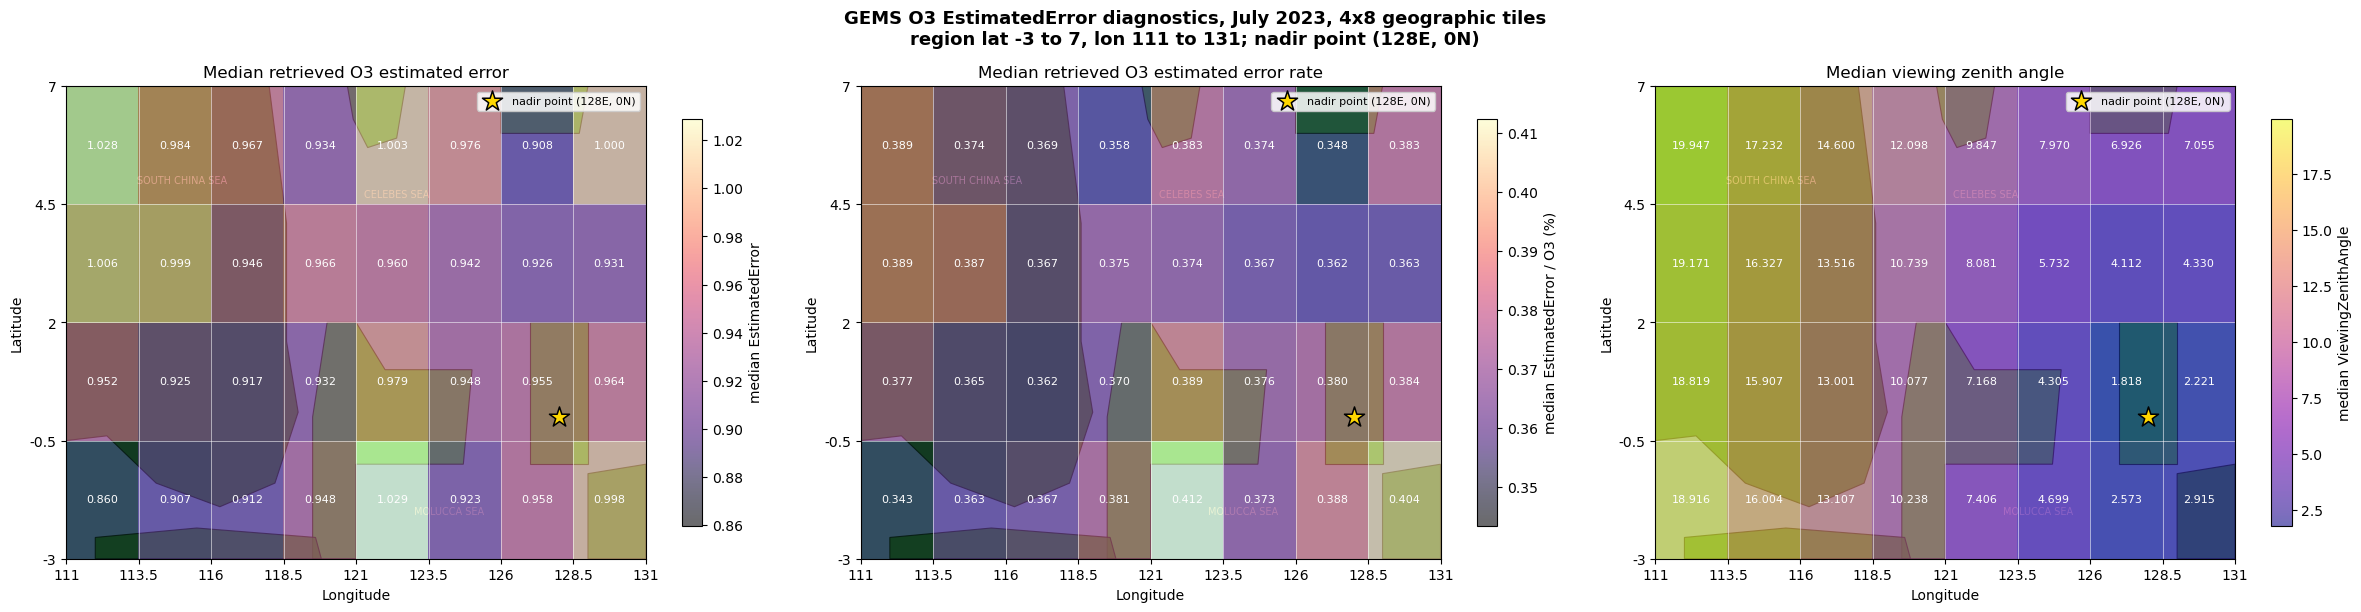

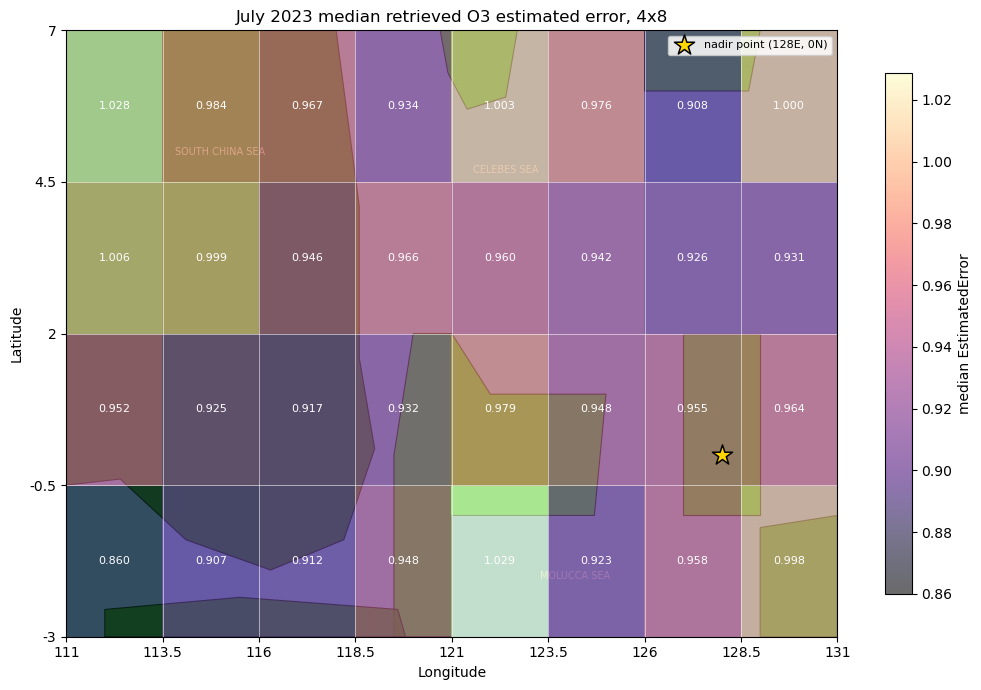

Saved: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/uncertainty_exploration/estimated_error_tile_summary_july_2023_4x8_geo.csv
Saved: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/uncertainty_exploration/estimated_error_vza_tile_july_2023_4x8_geo.png
Saved: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/uncertainty_exploration/estimated_error_tile_july_2023_4x8_geo.png


,tile_y,tile_x,n_files,total_n,median_error,mean_error,median_vza,median_sza,median_o3,mean_o3,median_error_pct,tile_lat_min,tile_lat_max,tile_lon_min,tile_lon_max,tile_lat_center,tile_lon_center
0,0,0,247,1010940,0.8599,1.1080,18.916100,34.288898,250.393799,250.484497,0.3434,-3.0,-0.5,111.0,113.5,-1.75,112.25
1,0,1,248,1052278,0.9067,1.0587,16.003901,37.289600,249.850693,249.865097,0.3629,-3.0,-0.5,113.5,116.0,-1.75,114.75
2,0,2,248,1056038,0.9123,1.0922,13.106700,37.187599,248.450394,249.116699,0.3672,-3.0,-0.5,116.0,118.5,-1.75,117.25
3,0,3,248,1098696,0.9478,1.1318,10.238400,36.976601,248.931595,249.224304,0.3807,-3.0,-0.5,118.5,121.0,-1.75,119.75
4,0,4,248,1066625,1.0287,1.3044,7.406400,36.991299,249.455399,249.203598,0.4124,-3.0,-0.5,121.0,123.5,-1.75,122.25
5,0,5,248,1107187,0.9228,1.1131,4.698700,36.561001,247.128494,247.598907,0.3734,-3.0,-0.5,123.5,126.0,-1.75,124.75
6,0,6,248,1109927,0.9581,1.1662,2.573100,36.534100,246.663498,247.039993,0.3884,-3.0,-0.5,126.0,128.5,-1.75,127.25
7,0,7,248,1094947,0.9980,1.2209,2.914700,36.686298,247.188400,247.236404,0.4037,-3.0,-0.5,128.5,131.0,-1.75,129.75
8,1,0,247,1038313,0.9516,1.1203,18.819000,32.436401,252.229095,253.158295,0.3773,-0.5,2.0,111.0,113.5,0.75,112.25
9,1,1,248,1061166,0.9249,1.1160,15.906700,35.778099,253.198898,253.752502,0.3653,-0.5,2.0,113.5,116.0,0.75,114.75


In [12]:
# Geographic 4x8 tile plot with the same longitude/latitude blocks and nadir marker as the nugget heatmaps.
# Run the batch-summary cell above first. If `batch_summary` is not in memory, this cell reads the saved CSV.

NY, NX = 4, 8
# Nadir and optional map-background settings are defined in the setup cell.


def _years_tag(years):
    return "_".join(map(str, years))


def _years_title(years):
    years = list(map(int, years))
    return f"July {years[0]}" if len(years) == 1 else f"July {min(years)}-{max(years)}"


def _fmt_geo_tick(x: float) -> str:
    return f"{x:.2f}".rstrip("0").rstrip(".")


def _load_map_background():
    if not USE_RASTER_MAP_BACKGROUND or MAP_BACKGROUND_PATH is None or not Path(MAP_BACKGROUND_PATH).exists():
        return None
    img = Image.open(MAP_BACKGROUND_PATH).convert("RGB")
    if MAP_BACKGROUND_CROP is not None:
        img = img.crop(MAP_BACKGROUND_CROP)
    return np.asarray(img)




def _draw_schematic_map_background(ax):
    if not USE_SCHEMATIC_MAP_BACKGROUND:
        return

    # Coarse regional land/water context for comparison with the nugget tile map.
    # It is not a coastline product; it is a lightweight geographic guide.
    ax.set_facecolor("#77b7de")
    land_specs = [
        ("Borneo / Kalimantan", [(111.0, 7.0), (118.0, 7.0), (118.6, 4.1), (118.6, 1.6),
                                  (119.0, 0.1), (118.2, -1.4), (116.3, -1.9), (114.1, -1.4),
                                  (112.4, -0.4), (111.0, -0.5)], "#1b7f2a"),
        ("Sulawesi", [(119.5, -3.0), (121.0, -3.0), (121.0, -1.0), (124.7, -1.0),
                       (125.0, 1.0), (122.0, 1.0), (121.0, 2.0), (120.0, 2.0),
                       (119.5, 0.0)], "#2fcf32"),
        ("Mindanao", [(126.0, 6.0), (128.7, 6.0), (129.0, 7.0), (126.0, 7.0)], "#2fbf38"),
        ("Halmahera", [(127.0, -1.0), (129.0, -1.0), (129.0, 2.0), (127.0, 2.0)], "#2fcf32"),
        ("Java / Lesser Sunda", [(112.0, -3.0), (119.8, -3.0), (119.6, -2.55),
                                  (115.5, -2.35), (112.0, -2.55)], "#208f2a"),
        ("Philippines", [(120.7, 7.0), (122.7, 7.0), (122.4, 5.9), (121.4, 5.7),
                         (120.9, 6.3)], "#2fbf38"),
        ("West Papua", [(129.0, -3.0), (131.0, -3.0), (131.0, -1.0), (129.0, -1.2)], "#238f35"),
    ]
    for _, coords, color in land_specs:
        ax.add_patch(
            Polygon(coords, closed=True, facecolor=color, edgecolor="#07351f", lw=0.8, alpha=0.82, zorder=0)
        )

    label_style = dict(color="white", fontsize=7, alpha=0.65, ha="center", va="center", zorder=0.2)
    ax.text(115.0, 5.0, "SOUTH CHINA SEA", **label_style)
    ax.text(122.4, 4.7, "CELEBES SEA", **label_style)
    ax.text(124.2, -2.0, "MOLUCCA SEA", **label_style)


def _load_batch_summary_for_plot() -> pd.DataFrame:
    if "batch_summary" in globals() and isinstance(batch_summary, pd.DataFrame) and len(batch_summary):
        return batch_summary.copy()
    csv_path = OUT_DIR / f"estimated_error_tile_summary_july_{_years_tag(BATCH_YEARS)}.csv"
    if not csv_path.exists():
        raise FileNotFoundError(
            f"Missing {csv_path}. Run the batch-summary cell first, or set BATCH_YEARS to match an existing CSV."
        )
    return pd.read_csv(csv_path)


def summarize_tiles_for_geo_plot(df: pd.DataFrame) -> pd.DataFrame:
    agg_spec = dict(
        n_files=("file", "nunique"),
        total_n=("n", "sum"),
        median_error=("median_error", "median"),
        mean_error=("mean_error", "mean"),
        median_vza=("median_vza", "median"),
        median_sza=("median_sza", "median"),
    )
    if "median_o3" in df.columns:
        agg_spec["median_o3"] = ("median_o3", "median")
    if "mean_o3" in df.columns:
        agg_spec["mean_o3"] = ("mean_o3", "mean")

    out = (
        df.groupby(["tile_y", "tile_x"])
        .agg(**agg_spec)
        .reset_index()
    )
    if "median_o3" in out.columns:
        out["median_error_pct"] = 100.0 * out["median_error"] / out["median_o3"]

    lat_edges = np.linspace(LAT_RANGE[0], LAT_RANGE[1], NY + 1)
    lon_edges = np.linspace(LON_RANGE[0], LON_RANGE[1], NX + 1)
    out["tile_lat_min"] = out["tile_y"].map(lambda y: lat_edges[int(y)])
    out["tile_lat_max"] = out["tile_y"].map(lambda y: lat_edges[int(y) + 1])
    out["tile_lon_min"] = out["tile_x"].map(lambda x: lon_edges[int(x)])
    out["tile_lon_max"] = out["tile_x"].map(lambda x: lon_edges[int(x) + 1])
    out["tile_lat_center"] = 0.5 * (out["tile_lat_min"] + out["tile_lat_max"])
    out["tile_lon_center"] = 0.5 * (out["tile_lon_min"] + out["tile_lon_max"])
    return out


def tile_matrix(summary: pd.DataFrame, value_col: str) -> np.ndarray:
    mat = np.full((NY, NX), np.nan, dtype=float)
    for row in summary.itertuples(index=False):
        mat[int(row.tile_y), int(row.tile_x)] = float(getattr(row, value_col))
    return mat


def draw_geo_tile_heatmap(ax, mat, title, cbar_label, cmap="viridis", background=None):
    lat_edges = np.linspace(LAT_RANGE[0], LAT_RANGE[1], NY + 1)
    lon_edges = np.linspace(LON_RANGE[0], LON_RANGE[1], NX + 1)
    extent = [lon_edges[0], lon_edges[-1], lat_edges[0], lat_edges[-1]]
    has_background = bool(USE_SCHEMATIC_MAP_BACKGROUND) or background is not None
    if USE_SCHEMATIC_MAP_BACKGROUND:
        _draw_schematic_map_background(ax)
    if background is not None:
        ax.imshow(background, extent=extent, origin="upper", aspect="auto", alpha=MAP_BACKGROUND_ALPHA, zorder=0)
    tile_alpha = TILE_ALPHA_WITH_BACKGROUND if has_background else TILE_ALPHA_NO_BACKGROUND
    im = ax.imshow(mat, origin="lower", cmap=cmap, extent=extent, aspect="auto", alpha=tile_alpha, zorder=1)

    for lon in lon_edges:
        ax.axvline(lon, color="white", lw=0.7, alpha=0.55, zorder=2)
    for lat in lat_edges:
        ax.axhline(lat, color="white", lw=0.7, alpha=0.55, zorder=2)

    lon_centers = 0.5 * (lon_edges[:-1] + lon_edges[1:])
    lat_centers = 0.5 * (lat_edges[:-1] + lat_edges[1:])
    finite_vals = mat[np.isfinite(mat)]
    vmin = float(np.nanmin(finite_vals)) if finite_vals.size else 0.0
    vmax = float(np.nanmax(finite_vals)) if finite_vals.size else 1.0
    threshold = vmin + 0.55 * (vmax - vmin)

    for y_idx, lat in enumerate(lat_centers):
        for x_idx, lon in enumerate(lon_centers):
            val = mat[y_idx, x_idx]
            if not np.isfinite(val):
                ax.text(lon, lat, "NA", ha="center", va="center", fontsize=8, color="white")
                continue
            color = "white" if (has_background or val > threshold) else "black"
            ax.text(lon, lat, f"{val:.3f}", ha="center", va="center", fontsize=8, color=color, zorder=3)

    if extent[0] <= NADIR_LON <= extent[1] and extent[2] <= NADIR_LAT <= extent[3]:
        ax.scatter(
            [NADIR_LON], [NADIR_LAT], marker="*", s=230, c="gold",
            edgecolors="black", linewidths=1.1,
            label="nadir point (128E, 0N)", zorder=5,
        )
        ax.legend(loc="upper right", fontsize=8, framealpha=0.85)

    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_xticks(lon_edges)
    ax.set_yticks(lat_edges)
    ax.set_xticklabels([_fmt_geo_tick(x) for x in lon_edges])
    ax.set_yticklabels([_fmt_geo_tick(y) for y in lat_edges])
    cbar = ax.figure.colorbar(im, ax=ax, shrink=0.86)
    cbar.set_label(cbar_label)


plot_input = _load_batch_summary_for_plot()
tile_geo = summarize_tiles_for_geo_plot(plot_input)
years_tag = _years_tag(BATCH_YEARS)
years_title = _years_title(BATCH_YEARS)
summary_geo_path = OUT_DIR / f"estimated_error_tile_summary_july_{years_tag}_4x8_geo.csv"
tile_geo.round(6).to_csv(summary_geo_path, index=False)

error_mat = tile_matrix(tile_geo, "median_error")
vza_mat = tile_matrix(tile_geo, "median_vza")
has_error_rate = "median_error_pct" in tile_geo.columns
rate_mat = tile_matrix(tile_geo, "median_error_pct") if has_error_rate else None
background = _load_map_background()

ncols = 3 if has_error_rate else 2
fig, axes = plt.subplots(1, ncols, figsize=(8.0 * ncols, 6.2))
axes = np.atleast_1d(axes)
fig.suptitle(
    f"GEMS O3 EstimatedError diagnostics, {years_title}, 4x8 geographic tiles\n"
    f"region lat {LAT_RANGE[0]:g} to {LAT_RANGE[1]:g}, lon {LON_RANGE[0]:g} to {LON_RANGE[1]:g}; "
    "nadir point (128E, 0N)",
    fontsize=13,
    fontweight="bold",
)

draw_geo_tile_heatmap(
    axes[0], error_mat,
    "Median retrieved O3 estimated error",
    "median EstimatedError",
    cmap="magma",
    background=background,
)
if has_error_rate:
    draw_geo_tile_heatmap(
        axes[1], rate_mat,
        "Median retrieved O3 estimated error rate",
        "median EstimatedError / O3 (%)",
        cmap="magma",
        background=background,
    )
    vza_ax = axes[2]
else:
    vza_ax = axes[1]

draw_geo_tile_heatmap(
    vza_ax, vza_mat,
    "Median viewing zenith angle",
    "median ViewingZenithAngle",
    cmap="plasma",
    background=background,
)

plt.tight_layout()
out_combined = OUT_DIR / f"estimated_error_vza_tile_july_{years_tag}_4x8_geo.png"
plt.savefig(out_combined, dpi=180, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10.5, 7.0))
draw_geo_tile_heatmap(
    ax, error_mat,
    f"{years_title} median retrieved O3 estimated error, 4x8",
    "median EstimatedError",
    cmap="magma",
    background=background,
)
plt.tight_layout()
out_error = OUT_DIR / f"estimated_error_tile_july_{years_tag}_4x8_geo.png"
plt.savefig(out_error, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", summary_geo_path)
print("Saved:", out_combined)
print("Saved:", out_error)
display(tile_geo.round(4))
